Encoder and patchifier tests


In [13]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import os
import sys

import cv2

import numpy as np 

import torch
import torch.nn as nn
import torch.nn.functional as F

from box import Box
import yaml

import matplotlib.pyplot as plt

root_dir = os.path.abspath('../..')
if root_dir not in sys.path:
    sys.path.append(root_dir)

from src.models.encoders import Encoder
from src.data_loader.transforms_numpy import polar2cartesian, addSpeckleNoise, energyLoss, addBandReflects



## 1. Encoder test

> Test of modules from `./src/models/encoders.py`.

> Responsible for creating features map and context map. 

In [15]:
from src.data_loader.transforms_numpy import polar2cartesian, addSpeckleNoise, energyLoss, addBandReflects

In [16]:
# additional fcn - convert sample type and shape
def convert_test_sample(frame, noise = False):

    # add noise 
    if noise:
        frame = addBandReflects(frame, omega1 = 0.03, omega2 = 0.07, gain = 0.02)
        frame = addSpeckleNoise(frame, m_min = 30, m_max = 100, sigma = 0.25, beam_width=2.0)

    # convert to torch tensor 
    frame = frame.astype(np.uint8)
    frame = torch.from_numpy(frame) # convert to torch tensor
    frame = frame.float().unsqueeze(0).unsqueeze(0).unsqueeze(0) # dtype, add dimensions: batch, frame in series, channels

    return frame

In [17]:
# test data
data_pth_sim = f'C:/Users/janis/Projekty/Magisterka/SonarOdometry/data/seq_1/fls/352.png'
data_pth_real = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/data/aracati/data_example/1500.png'

# read frame 
frame_sim = cv2.imread(data_pth_sim, 0)
frame_real = cv2.imread(data_pth_real, 0)

frame_sim_noise = convert_test_sample(frame_sim, noise = True)
frame_real_noise = convert_test_sample(frame_real, noise = False)

print('-'*80)
print(f'Input data format:')
print(f'simulated tensor shape: {frame_sim_noise.shape}, data type: {frame_sim_noise.dtype}')
print(f'real tensor shape: {frame_real_noise.shape}, data type: {frame_real_noise.dtype}')
print('-'*80)

--------------------------------------------------------------------------------
Input data format:
simulated tensor shape: torch.Size([1, 1, 1, 800, 768]), data type: torch.float32
real tensor shape: torch.Size([1, 1, 1, 848, 1553]), data type: torch.float32
--------------------------------------------------------------------------------


In [18]:
# instance of encoder 
model_encoder = Encoder(in_ch = 1, out_ch = 128, dim = 32, dropout=0.5, norm_fn ='instance') 

In [ ]:
# pass through encoder

output_sim = model_encoder(frame_sim_noise)
output_real = model_encoder(frame_real_noise)

print('-'*80)
print(f'Output data format:')
print(f'simulated tensor shape: {output_sim.shape}, data type: {output_sim.dtype}')
print(f'real tensor shape: {output_real.shape}, data type: {output_real.dtype}')
print('-'*80)

--------------------------------------------------------------------------------
Output data format:
simulated tensor shape: torch.Size([1, 128, 200, 192]), data type: torch.float32
real tensor shape: torch.Size([1, 128, 212, 389]), data type: torch.float32
--------------------------------------------------------------------------------


## 2. Patch extraction test

> Test of modules from `./src/models/patchifier.py`.

> Responsible for selection of keypoints for patches and extraction of patches from features map from coords corresponding to key points.

In [20]:
from src.models.patchifier import Patchifier

In [24]:
config_file_pth = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/config/model.yaml'

with open(config_file_pth, "r") as f:
    config = Box(yaml.safe_load(f))

patchifier = Patchifier(config, debug_mode = True)

# del config

''' 
If debug mode, you can acces some debug data from dictionary. 

    patchifier.debug_dict['key']

Available keys:
> 'harris_response' - harris response used to find keypoints, np.array, uint8
> 'key_points' - input frame with drawn keypoints and gird
'''


" \nIf debug mode, you can acces some debug data from dictionary. \n\n    patchifier.debug_dict['key']\n\nAvailable keys:\n> 'harris_response' - harris response used to find keypoints, np.array, uint8\n> 'key_points' - input frame with drawn keypoints and gird\n"

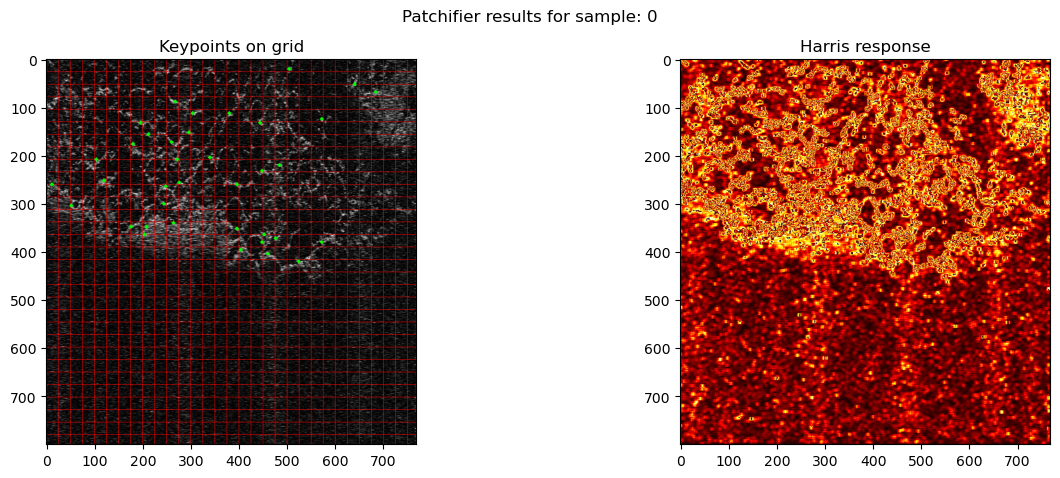

Details:
> Output shapes:
  - coords: list of coordinates (x, y) of patch central points.
    shape: torch.Size([1, 40, 2])
  - patches: tensor with extracted patches
    shape: torch.Size([1, 40, 128, 3, 3])
  - fmaps: features map of frame
    shape: torch.Size([1, 128, 200, 192])
  - imap: context map of frame
    shape: torch.Size([1, 128, 200, 192])


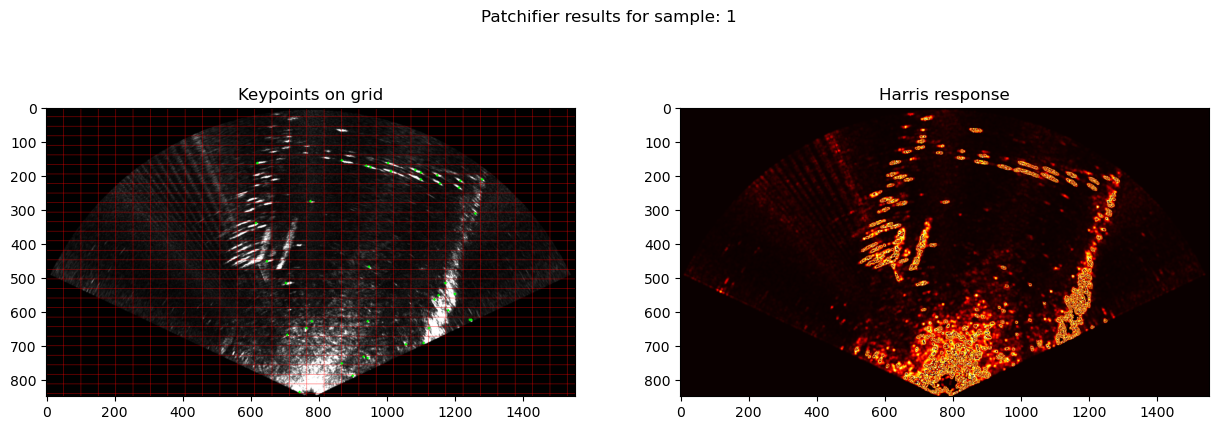

Details:
> Output shapes:
  - coords: list of coordinates (x, y) of patch central points.
    shape: torch.Size([1, 40, 2])
  - patches: tensor with extracted patches
    shape: torch.Size([1, 40, 128, 3, 3])
  - fmaps: features map of frame
    shape: torch.Size([1, 128, 212, 389])
  - imap: context map of frame
    shape: torch.Size([1, 128, 212, 389])


In [28]:
# pass input sample image through patchifier module

test_data = (frame_sim_noise, frame_real_noise)

for idx, frame in enumerate(test_data):

    coords, patches, fmap, imap = patchifier(frame, mode = 'harris')

    # get from debug dict key frames
    debug_keypoints = patchifier.debug_dict['key_points']
    debug_harrisresponse = patchifier.debug_dict['harris_response']

    fig, ax = plt.subplots(1, 2, figsize = (15,5))
    fig.suptitle(f'Patchifier results for sample: {idx}')

    ax[0].set_title('Keypoints on grid')
    ax[0].imshow(debug_keypoints)


    ax[1].set_title('Harris response')
    ax[1].imshow(debug_harrisresponse, cmap='hot')

    plt.show()

    print('='*80)
    print('Details:')
    print(f'> Output shapes:')
    print(f'  - coords: list of coordinates (x, y) of patch central points.\n    shape: {coords.shape}')
    print(f'  - patches: tensor with extracted patches\n    shape: {patches.shape}')
    print(f'  - fmaps: features map of frame\n    shape: {fmap.shape}')
    print(f'  - imap: context map of frame\n    shape: {imap.shape}')
    print('='*80)
    
    



# 3. Graph module test

> Test of modules from `./src/models/graph.py`.

> Responsible for operating graph and frames processing

In [ ]:
from src.models.graph import Graph

from src.data_loader.data_loader import data_headers as h # headers of csv file

In [ ]:
data_pth = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/data/seq_1/fls'
data_csv_pth = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/data/seq_1/sequence.csv'
model_config_file_pth = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/config/model.yaml'
sonar_config_file_pth = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/config/sonar.yaml'

with open(model_config_file_pth, "r") as f:
    model_config = Box(yaml.safe_load(f))

with open(sonar_config_file_pth, "r") as f:
    sonar_config = Box(yaml.safe_load(f))

PatchGraph = Graph(model_config, sonar_config)

In [ ]:
loop_size = 15

# dataframe for csv data
data_reader = np.loadtxt(data_csv_pth, delimiter = ',', skiprows=1) # read data from csv 

# Loop through frames
for frame_no in range(loop_size):
    frame_name = os.path.join(data_pth, f'{frame_no}.png')
    frame = cv2.imread(frame_name, 0)
    
    # add noises
    noise_frame = addBandReflects(new_frame, omega1 = 0.03, omega2 = 0.07, gain = 0.02)
    # noise_frame = energyLoss(noise_frame, alpha = 0.02)
    noise_frame = addSpeckleNoise(noise_frame, m_min = 30, m_max = 100, sigma = 0.25, beam_width=2.0)
    noise_frame = noise_frame.astype(np.uint8)

    # to tensor
    sample = torch.from_numpy(noise_frame.copy()) # convert to torch tensor
    sample = sample.float()
    sample = sample.unsqueeze(0).unsqueeze(0).unsqueeze(0) # add channels num dimension; # add batch size dimension; # add frame num in series dimension

    # get time stamp:
    time_stamp = data_reader[frame_no, h['t']]

    PatchGraph(sample, time_stamp)

    if not frame is None:   
        print(f'Frame [{frame_no}], t = {time_stamp} added to graph')


Frame [0], t = 0.0 added to graph
Frame [1], t = 1.002 added to graph
Frame [2], t = 2.171 added to graph
Frame [3], t = 2.972 added to graph
Frame [4], t = 3.708 added to graph
Frame [5], t = 4.51 added to graph
Frame [6], t = 5.245 added to graph
Frame [7], t = 6.381 added to graph
Frame [8], t = 7.517 added to graph
Frame [9], t = 8.687 added to graph
Frame [10], t = 9.489 added to graph
Frame [11], t = 10.224 added to graph
Frame [12], t = 11.027 added to graph
Frame [13], t = 11.761 added to graph
Frame [14], t = 12.897 added to graph


In [ ]:
# check some data after sequence frocessing

# 1. Global graph index
print('='*40)
print(f'Check if graph global idx is correct')
print(f'Global graph idx: {PatchGraph.frame_n} (expected: {loop_size})')

# 2. Check if correct number of frames is added to frame graph 
print('='*40)
print(f'Check if correct number of frames is added ')
buff_size = config.BUFF_SIZE
error = {}
for i in range(buff_size):
    sum = torch.sum(PatchGraph.fmap[i, :, :, :]).detach().cpu().numpy()
    
    if i < loop_size:
        if sum != 0: pass # print(f'- {i} OK')
        else: 
            print(f'- {i} ERR')
            error.append(i)
    if i >= loop_size:
        if sum == 0: pass # print(f'- {i} OK')
        else: 
            print(f'- {i} ERR')
            error.append(i)

print(f'number of errors: {len(error)}')

Check if graph global idx is correct
Global graph idx: 15 (expected: 15)
Check if correct number of frames is added 
number of errors: 0
